In [1]:
!pip install ollama

In [2]:
!sudo apt update && sudo apt install pciutils lshw


Get:1 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease [1,581 B]
Get:2 https://cli.github.com/packages stable InRelease [3,917 B]
Get:3 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:4 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ Packages [88.5 kB]
Get:5 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  Packages [2,525 kB]
Get:6 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]      
Hit:7 http://archive.ubuntu.com/ubuntu jammy InRelease                         
Get:8 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]        
Get:9 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease [18.1 kB]
Get:10 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]          
Hit:11 https://ppa.launchpadcontent.net/graphics-drivers/ppa/ubuntu jammy InRelease
Hit:12 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRe

In [3]:
!apt-get install -y zstd

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  zstd
0 upgraded, 1 newly installed, 0 to remove and 74 not upgraded.
Need to get 603 kB of archives.
After this operation, 1,695 kB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/main amd64 zstd amd64 1.4.8+dfsg-3build1 [603 kB]
Fetched 603 kB in 2s (394 kB/s)
Selecting previously unselected package zstd.
(Reading database ... 122387 files and directories currently installed.)
Preparing to unpack .../zstd_1.4.8+dfsg-3build1_amd64.deb ...
Unpacking zstd (1.4.8+dfsg-3build1) ...
Setting up zstd (1.4.8+dfsg-3build1) ...
Processing triggers for man-db (2.10.2-1) ...


In [4]:
!curl -fsSL https://ollama.com/install.sh | sh

>>> Installing ollama to /usr/local
>>> Downloading ollama-linux-amd64.tar.zst
######################################################################## 100.0%
>>> Creating ollama user...
>>> Adding ollama user to video group...
>>> Adding current user to ollama group...
>>> Creating ollama systemd service...
>>> NVIDIA GPU installed.
>>> The Ollama API is now available at 127.0.0.1:11434.
>>> Install complete. Run "ollama" from the command line.


In [5]:
import subprocess
import time
def run_ollama_serve():
    subprocess.Popen(["ollama", "serve"])

run_ollama_serve()
time.sleep(5) 

In [6]:
!ollama signin

You need to be signed in to Ollama to run Cloud models.

/usr/bin/xdg-open: 882: www-browser: not found
/usr/bin/xdg-open: 882: links2: not found
/usr/bin/xdg-open: 882: elinks: not found
/usr/bin/xdg-open: 882: links: not found
/usr/bin/xdg-open: 882: lynx: not found
/usr/bin/xdg-open: 882: w3m: not found
xdg-open: no method available for opening 'https://ollama.com/connect?name=f1f7e9c143e1&key=c3NoLWVkMjU1MTkgQUFBQUMzTnphQzFsWkRJMU5URTVBQUFBSUp0YnQ1eDk1RmFReWFlaFFSYmVtR1IwVGhjTklhUXFObEk1eFNuVzlyTmk'
If your browser did not open, navigate to:
    https://ollama.com/connect?name=f1f7e9c143e1&key=c3NoLWVkMjU1MTkgQUFBQUMzTnphQzFsWkRJMU5URTVBQUFBSUp0YnQ1eDk1RmFReWFlaFFSYmVtR1IwVGhjTklhUXFObEk1eFNuVzlyTmk



## 2. Imports

In [7]:
import os, json, torch
import numpy as np
from tqdm.notebook import tqdm
from ollama import Client
from datasets import load_dataset
from transformers import AutoTokenizer, AutoModelForCausalLM
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report
print('PyTorch :', torch.__version__)
print('Device  :', 'cuda' if torch.cuda.is_available() else 'cpu')

PyTorch : 2.10.0+cu128
Device  : cuda


## 3. Configuration

In [8]:
MODEL_CONFIGS = {
    "qwen2.5-1.5b": {
        "hf_name": "Qwen/Qwen2.5-1.5B-Instruct",
        "num_layers": 28,
        "intermediate_size": 8960,
        "no_think": False,
    },
    "qwen3-1.7b": {
        "hf_name": "Qwen/Qwen3-1.7B",
        "num_layers": 28,
        "intermediate_size": 8192,
        "no_think": True,
    },
    "qwen3-4b": {
        "hf_name": "Qwen/Qwen3-4B",
        "num_layers": 36,
        "intermediate_size": 11008,
        "no_think": True,
    },
    "llama-3.1-8b": {
        "hf_name": "meta-llama/Llama-3.1-8B-Instruct",
        "num_layers": 32,
        "intermediate_size": 14336,
        "no_think": False,
    },
}

MODEL_KEY = "qwen2.5-1.5b"  # ← change this to switch models
cfg = MODEL_CONFIGS[MODEL_KEY]
MODEL_NAME = cfg["hf_name"]
NUM_LAYERS = cfg["num_layers"]
INTERMEDIATE_SIZE = cfg["intermediate_size"]
NO_THINK = cfg.get("no_think", False)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
JUDGE_MODEL = "gpt-oss:120b-cloud"
NUM_QUERIES = 100
SAMPLES_PER_QUERY = 10
MAX_NEW_TOKENS = 50
TEMPERATURE = 0.1
TOP_P = 0.95
LASSO_C = 0.01
MAX_ITER = 1000
OUTPUT_DIR = f"h_neuron_results_{MODEL_KEY}"
import os

os.makedirs(OUTPUT_DIR, exist_ok=True)
print(f"Model : {MODEL_NAME}")
print(f"Output: {OUTPUT_DIR}")

Model : Qwen/Qwen2.5-1.5B-Instruct
Output: h_neuron_results_qwen2.5-1.5b


## 4. Initialise Ollama Client

In [9]:
client = Client()
try:
    available = [m.model for m in client.list().models]
    print("Local Ollama models:", available)
    if JUDGE_MODEL not in available:
        
        print(f"Note: '{JUDGE_MODEL}' not local — will be routed to cloud.")
except Exception as e:
    print("Ollama ping:", e)

Local Ollama models: []
Note: 'gpt-oss:120b-cloud' not local — will be routed to cloud.


## 5. Load Qwen 2.5-1.5B-Instruct

In [ ]:
!hf auth login --token TOKEN

A new version of huggingface_hub (1.10.1) is available! You are using version 1.8.0.
To update, run: pip install -U huggingface_hub

The token has not been saved to the git credentials helper. Pass `add_to_git_credential=True` in this function directly or `--add-to-git-credential` if using via `hf`CLI if you want to set the git credential as well.
Token is valid (permission: write).
The token `Hallucinations` has been saved to /root/.cache/huggingface/stored_tokens
Your token has been saved to /root/.cache/huggingface/token
Login successful.
The current active token is: `Hallucinations`


In [11]:
print(f"Loading {MODEL_NAME} ...")
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, trust_remote_code=True)
model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    torch_dtype=torch.float16 if DEVICE == "cuda" else torch.float32,
    device_map="auto",
    trust_remote_code=True,
)
model.eval()
NUM_LAYERS        = model.config.num_hidden_layers
HIDDEN_SIZE       = model.config.hidden_size
INTERMEDIATE_SIZE = model.config.intermediate_size
print(f"  Layers      : {NUM_LAYERS}")
print(f"  Hidden size : {HIDDEN_SIZE}")
print(f"  MLP size    : {INTERMEDIATE_SIZE}")

Loading Qwen/Qwen2.5-1.5B-Instruct ...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:104: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


config.json:   0%|          | 0.00/660 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

...

`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors:   0%|          | 0.00/3.09G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

  Layers      : 28
  Hidden size : 1536
  MLP size    : 8960


## 6. Ollama Judge Functions

Uses the same prompt structure and `<hallucination>` tag parsing as your evaluation code.

In [12]:
from concurrent.futures import ThreadPoolExecutor, as_completed

def judge_prompt(model_output, correct_output):
    return (
        "<prompt>\n"
        "You are an expert evaluator tasked with determining whether a language model's\n"
        "output contains hallucinations. A hallucination occurs when the model generates\n"
        "information that is factually incorrect, fabricated, or not supported by the\n"
        "correct output.\n\n"
        "<input>\n"
        "<model_output>\n"
        f"{model_output}\n"
        "</model_output>\n"
        "<correct_output>\n"
        f"{correct_output}\n"
        "</correct_output>\n"
        "</input>\n\n"
        "Compare the model output against the correct output. Determine if it contains:\n"
        "- Factually incorrect information\n"
        "- Fabricated details not present in the correct output\n"
        "- Contradictions to the correct output\n\n"
        "Note: Paraphrasing, different wording, or omissions are NOT hallucinations.\n\n"
        "Respond with only:\n"
        "- 0 if there is NO hallucination\n"
        "- 1 if there IS a hallucination\n\n"
        "<hallucination>{0 or 1}</hallucination>\n"
        "</prompt>"
    )


def judge_correctness(question, gold_answers, response):
    # gold_answers is now a list — join them for the judge prompt
    correct = " / ".join(gold_answers) if gold_answers else ""
    prompt = judge_prompt(model_output=response, correct_output=correct)
    result = client.chat(
        model=JUDGE_MODEL, messages=[{"role": "user", "content": prompt}]
    )
    content = result.message.content
    try:
        label = int(
            content.split("<hallucination>")[1].split("</hallucination>")[0].strip()
        )
    except (IndexError, ValueError):
        label = 1 if "1" in content else 0
    return label == 0


def judge_batch(examples, max_workers=8):
    with ThreadPoolExecutor(max_workers=max_workers) as pool:
        futures = {
            pool.submit(
                judge_correctness, ex["question"], ex["gold_aliases"], ex["response"]
            ): i
            for i, ex in enumerate(examples)
        }
        results = [None] * len(examples)
        for fut in as_completed(futures):
            idx = futures[fut]
            results[idx] = fut.result()
    return results


def span_prompt(question, response):
    return (
        "<prompt>\n"
        "You are a precise text extractor.\n\n"
        "<input>\n"
        f"<question>{question}</question>\n"
        f"<response>{response}</response>\n"
        "</input>\n\n"
        "Extract and return only the exact substring from the response that contains\n"
        "the factual answer to the question. No punctuation, no explanation.\n\n"
        "<answer_span>{exact substring}</answer_span>\n"
        "</prompt>"
    )


def extract_answer_span_batch(questions, responses):
    batch_prompt = ""

    for i, (q, r) in enumerate(zip(questions, responses)):
        batch_prompt += f"""
Example {i}:
Question: {q}
Response: {r}

Return:
<answer_span>...</answer_span>

"""

    result = client.chat(
        model=JUDGE_MODEL, messages=[{"role": "user", "content": batch_prompt}]
    )

    content = result.message.content

    # Parse all spans
    spans = []
    parts = content.split("<answer_span>")[1:]

    for part in parts:
        try:
            span = part.split("</answer_span>")[0].strip()
        except IndexError:
            span = ""
        spans.append(span)

    # fallback if mismatch
    while len(spans) < len(questions):
        spans.append("")

    return spans


print("Ollama judge functions defined.")

Ollama judge functions defined.


## 7. Generation Helpers

In [13]:
import re


def strip_thinking(response):
    return re.sub(r"<think>.*?</think>", "", response, flags=re.DOTALL).strip()


def build_prompt(question):
    messages = [
        {
            "role": "system",
            "content": "Answer the following question concisely and factually.",
        },
        {"role": "user", "content": question},
    ]
    try:
        return tokenizer.apply_chat_template(
            messages, tokenize=False, add_generation_prompt=True, enable_thinking=False
        )
    except TypeError:
        return tokenizer.apply_chat_template(
            messages, tokenize=False, add_generation_prompt=True
        )


def sample_responses(prompt, k):
    inputs = tokenizer(prompt, return_tensors="pt").to(DEVICE)
    input_ids = inputs["input_ids"].expand(k, -1)  # repeat prompt k times
    attention_mask = inputs["attention_mask"].expand(k, -1)

    with torch.no_grad():
        outputs = model.generate(
            input_ids=input_ids,
            attention_mask=attention_mask,
            max_new_tokens=MAX_NEW_TOKENS,
            do_sample=True,
            temperature=TEMPERATURE,
            top_p=TOP_P,
            pad_token_id=tokenizer.eos_token_id,
        )

    prompt_len = inputs["input_ids"].shape[-1]
    responses = []
    for i in range(k):
        gen_ids = outputs[i][prompt_len:]
        raw = tokenizer.decode(gen_ids, skip_special_tokens=True).strip()
        responses.append(strip_thinking(raw) if NO_THINK else raw)
    return responses


print("Generation helpers defined.")

Generation helpers defined.


## 8. Sample Responses & Consistency Filter
Longest step. Checkpointed every 10 queries.

In [ ]:
import time
import random
import json
from concurrent.futures import ThreadPoolExecutor, as_completed
from pathlib import Path

import pandas as pd
from datasets import load_dataset
from tqdm import tqdm

# =========================
# CONFIG
# =========================
MAX_CONCURRENT_REQUESTS = 6
REQUEST_DELAY = 0.15
MAX_RETRIES = 3
NUM_QUERIES = 100  # adjust as needed
SAMPLES_PER_QUERY = 5  # adjust as needed
CHECKPOINT_EVERY = 10
OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(exist_ok=True)


# =========================
# HELPERS
# =========================
def retry_with_backoff(fn, *args, **kwargs):
    """Retry wrapper with exponential backoff."""
    for attempt in range(MAX_RETRIES):
        try:
            return fn(*args, **kwargs)
        except Exception as e:
            if attempt == MAX_RETRIES - 1:
                raise e
            sleep_time = (2**attempt) + random.uniform(0, 0.5)
            print(
                f"  [retry {attempt+1}/{MAX_RETRIES}] sleeping {sleep_time:.1f}s — {e}"
            )
            time.sleep(sleep_time)


def safe_judge(question, gold_answers, response):
    """Rate-limited + retry-protected judge call."""
    time.sleep(REQUEST_DELAY)
    return retry_with_backoff(judge_correctness, question, gold_answers, response)


def judge_responses_parallel(question, gold_answers, responses):
    """Controlled parallel judging."""
    results = [None] * len(responses)
    with ThreadPoolExecutor(max_workers=MAX_CONCURRENT_REQUESTS) as executor:
        futures = {
            executor.submit(safe_judge, question, gold_answers, r): i
            for i, r in enumerate(responses)
        }
        for future in as_completed(futures):
            idx = futures[future]
            results[idx] = future.result()
    return results


def save_checkpoint(examples, step):
    """Save a mid-run checkpoint as parquet."""
    path = OUTPUT_DIR / f"checkpoint_{step}.parquet"
    pd.DataFrame(examples).to_parquet(path, index=False)
    print(f"  [checkpoint] saved {len(examples)} examples → {path}")


def save_final(examples):
    """Save final outputs: parquet + JSON."""
    df = pd.DataFrame(examples)

    parquet_path = OUTPUT_DIR / "consistent_examples.parquet"
    df.to_parquet(parquet_path, index=False)
    print(f"Saved parquet → {parquet_path}")

    json_path = OUTPUT_DIR / "consistent_examples.json"
    with open(json_path, "w") as f:
        json.dump(examples, f, indent=2)
    print(f"Saved JSON   → {json_path}")

    return df


# =========================
# MAIN PIPELINE
# =========================
def process_question(item):
    question = item["Question"]
    gold_answers = item["Correct Answers"]
    prompt = build_prompt(question)

    responses = [
        retry_with_backoff(sample_responses, prompt, 1)[0]
        for _ in range(SAMPLES_PER_QUERY)
    ]

    correctness = judge_responses_parallel(question, gold_answers, responses)
    n_correct = sum(correctness)

    if n_correct == SAMPLES_PER_QUERY:
        label = 0  # faithful
    elif n_correct == 0:
        label = 1  # hallucinatory
    else:
        return []  # skip inconsistent

    return [
        {
            "prompt": prompt,
            "response": r,
            "label": label,
            "question": question,
        }
        for r in responses
    ]


print("Loading TruthfulQA ...")
dataset = load_dataset("domenicrosati/TruthfulQA", split="train")
dataset = dataset.select(range(NUM_QUERIES))

consistent_examples = []

for i, item in enumerate(tqdm(dataset, desc="Sampling & filtering")):
    try:
        consistent_examples.extend(process_question(item))
    except Exception as e:
        print(f"  [error] question {i} failed: {e}")

    time.sleep(0.3)

    if (i + 1) % CHECKPOINT_EVERY == 0:
        print(f"[{i+1}/{NUM_QUERIES}] kept: {len(consistent_examples)}")
        save_checkpoint(consistent_examples, i + 1)

# =========================
# FINAL SAVE + SUMMARY
# =========================
df = save_final(consistent_examples)

n_hall = (df["label"] == 1).sum()
n_faith = (df["label"] == 0).sum()

print(
    f"\nRetained {len(df)} examples — "
    f"Hallucinatory: {n_hall}  |  Faithful: {n_faith}"
)
print(df["label"].value_counts().to_string())

Loading TruthfulQA ...


README.md: 0.00B [00:00, ?B/s]

train.csv: 0.00B [00:00, ?B/s]

Generating train split:   0%|          | 0/817 [00:00<?, ? examples/s]

Sampling & filtering:  10%|█         | 10/100 [06:01<50:55, 33.95s/it] 

...

[80/100] kept: 490


Sampling & filtering:  90%|█████████ | 90/100 [1:00:09<07:26, 44.67s/it]

[90/100] kept: 530


Sampling & filtering: 100%|██████████| 100/100 [1:06:29<00:00, 39.89s/it]

[100/100] kept: 600
Retained 600 — Hallucinatory: 540  Faithful: 60


## 9. Extract Answer Token Spans

In [15]:
BATCH_SIZE = 5  # sweet spot for Ollama

for i in tqdm(range(0, len(consistent_examples), BATCH_SIZE), desc="Answer spans"):
    batch = consistent_examples[i : i + BATCH_SIZE]

    questions = [ex["question"] for ex in batch]
    responses = [
        strip_thinking(ex["response"]) if NO_THINK else ex["response"] for ex in batch
    ]

    spans = extract_answer_span_batch(questions, responses)

    for ex, resp_clean, span in zip(batch, responses, spans):
        ex["response_clean"] = resp_clean
        ex["answer_span"] = span if span else resp_clean[:80]

Answer spans: 100%|██████████| 120/120 [14:03<00:00,  7.03s/it]


## 10. Compute CETT Features

In [16]:
def get_mlp_hook_target(layer):
    mlp = layer.mlp
    if hasattr(mlp, "down_proj"):
        return mlp.down_proj
    else:
        raise ValueError(f"Unrecognized MLP structure: {list(mlp._modules.keys())}")

# Run this once before the CETT loop
print("Caching neuron norms ...")
CACHED_TARGETS = [get_mlp_hook_target(layer) for layer in model.model.layers]
CACHED_NEURON_NORMS = [
    torch.norm(t.weight.float(), dim=0).to(DEVICE) for t in CACHED_TARGETS
]
print("Done.")


def get_answer_token_mask(full_text, answer_span, input_ids):
    tokens = [tokenizer.decode([tid]) for tid in input_ids[0]]
    span_lower = answer_span.lower().strip()
    mask = torch.zeros(len(tokens), dtype=torch.bool)

    # Build cumulative string positions
    cumulative = ""
    positions = []
    for tok in tokens:
        start = len(cumulative)
        cumulative += tok
        positions.append((start, len(cumulative)))

    text_lower = cumulative.lower()
    hit = text_lower.find(span_lower)
    if hit == -1:
        return mask

    # Mark tokens that overlap with the found span
    hit_end = hit + len(span_lower)
    for i, (s, e) in enumerate(positions):
        if s < hit_end and e > hit:
            mask[i] = True

    return mask


class MlpNeuronHook:
    def __init__(self):
        self.activations = {}

    def hook_fn(self, layer_idx):
        def _hook(module, input, output):
            # input[0] is the vector fed into down_proj — correct for SwiGLU
            self.activations[layer_idx] = input[0].detach().float().squeeze(0)

        return _hook


class MeanPoolHook:
    def __init__(self):
        self.means = {}

    def hook_fn(self, layer_idx):
        def _h(module, input, output):
            # output is (batch, seq, hidden) — mean over seq immediately
            self.means[layer_idx] = output[0].float().mean(0).cpu().detach().numpy()

        return _h


def get_hidden_states_fast(example):
    full_text = example["prompt"] + example.get("response_clean", example["response"])
    inputs = tokenizer(full_text, return_tensors="pt").to(DEVICE)

    store = MeanPoolHook()
    hooks = [
        layer.register_forward_hook(store.hook_fn(li))
        for li, layer in enumerate(model.model.layers)
    ]
    with torch.no_grad():
        model(**inputs)  # no output_hidden_states needed
    for h in hooks:
        h.remove()

    return [store.means[li] for li in range(NUM_LAYERS)]


def compute_cett(example):
    full_text = example["prompt"] + example.get("response_clean", example["response"])
    inputs = tokenizer(full_text, return_tensors="pt").to(DEVICE)
    ans_mask = get_answer_token_mask(
        full_text, example["answer_span"], inputs["input_ids"]
    ).to(DEVICE)
    other_mask = ~ans_mask

    if ans_mask.sum() == 0:
        return None, None

    # Cache targets and W_down norms once
    # targets = [get_mlp_hook_target(layer) for layer in model.model.layers]
    # neuron_norms = [torch.norm(t.weight.float(), dim=0).to(DEVICE) for t in targets]
    targets = CACHED_TARGETS
    neuron_norms = CACHED_NEURON_NORMS

    hook_store = MlpNeuronHook()
    hooks = [
        t.register_forward_hook(hook_store.hook_fn(li)) for li, t in enumerate(targets)
    ]

    with torch.no_grad():
        outputs = model(**inputs, output_hidden_states=True)
    for h in hooks:
        h.remove()

    first_act = next(iter(hook_store.activations.values()))
    actual_intermediate = first_act.shape[-1]
    cett_answer = np.zeros((NUM_LAYERS, actual_intermediate), dtype=np.float32)
    cett_other = np.zeros((NUM_LAYERS, actual_intermediate), dtype=np.float32)

    for li in range(NUM_LAYERS):
        if li not in hook_store.activations:
            continue
        neuron_acts = hook_store.activations[li]
        h_total = outputs.hidden_states[li + 1].squeeze(0).float()
        h_norm = torch.norm(h_total, dim=-1, keepdim=True).clamp(min=1e-8)
        contribs = (neuron_acts.abs() * neuron_norms[li].unsqueeze(0)) / h_norm

        if ans_mask.sum() > 0:
            cett_answer[li] = contribs[ans_mask].mean(0).cpu().detach().numpy()
        if other_mask.sum() > 0:
            cett_other[li] = contribs[other_mask].mean(0).cpu().detach().numpy()

    return cett_answer, cett_other


print("Computing CETT features ...")
skipped = 0
for ex in tqdm(consistent_examples, desc="CETT"):
    ca, co = compute_cett(ex)
    if ca is None:
        skipped += 1
        continue
    ex["cett_answer"] = ca
    ex["cett_other"] = co

# Remove examples where span extraction failed
consistent_examples = [e for e in consistent_examples if "cett_answer" in e]
print(f"Done. Skipped {skipped} examples with empty answer spans.")

Caching neuron norms ...
Done.
Computing CETT features ...


CETT: 100%|██████████| 600/600 [00:35<00:00, 16.84it/s]

Done. Skipped 40 examples with empty answer spans.


## 11. Sparse L1 Probing → H-Neurons

Label scheme (Gao et al.):
- **Positive (y=1):** answer-token CETT from hallucinatory responses
- **Negative (y=0):** answer-token CETT from faithful responses + other-token CETT from both

In [17]:
assert (
    len(consistent_examples) > 0
), "No examples remaining after CETT — check span extraction"

X_rows, y_labels = [], []
for ex in consistent_examples:
    ca = ex["cett_answer"].flatten()
    co = ex["cett_other"].flatten()
    feat = np.concatenate([ca, co])
    if ex["label"] == 1:
        X_rows.append(feat)
        y_labels.append(1)
        X_rows.append(np.concatenate([np.zeros_like(ca), co]))
        y_labels.append(0)
    else:
        X_rows.append(feat)
        y_labels.append(0)

X = np.stack(X_rows).astype(np.float32)
y = np.array(y_labels, dtype=np.int32)
print(f"Feature matrix : {X.shape}  |  Pos: {y.sum()}  Neg: {(y==0).sum()}")

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

clf = LogisticRegression(
    penalty="l1",
    C=LASSO_C,
    solver="liblinear",
    max_iter=MAX_ITER,
    class_weight="balanced",
    random_state=42,
)
clf.fit(X_scaled, y)
print(
    classification_report(
        y, clf.predict(X_scaled), target_names=["faithful", "hallucinated"]
    )
)

Feature matrix : (1061, 501760)  |  Pos: 501  Neg: 560
              precision    recall  f1-score   support

    faithful       1.00      0.89      0.94       560
hallucinated       0.89      1.00      0.94       501

    accuracy                           0.94      1061
   macro avg       0.95      0.95      0.94      1061
weighted avg       0.95      0.94      0.94      1061



## 12. Extract & Inspect H-Neurons

In [18]:
actual_intermediate = consistent_examples[0]["cett_answer"].shape[1]
n_half = NUM_LAYERS * actual_intermediate
coef_answer_2d = clf.coef_[0][:n_half].reshape(NUM_LAYERS, actual_intermediate)
h_neuron_mask = coef_answer_2d > 0
h_neuron_count = int(h_neuron_mask.sum())

print(f"Model            : {MODEL_KEY}")
print(f"H-Neurons        : {h_neuron_count}")
print(
    f"Fraction of total: {100 * h_neuron_count / (NUM_LAYERS * actual_intermediate):.4f}%"
)

h_neurons = sorted(
    [
        {"layer": int(l), "neuron_idx": int(n), "weight": float(coef_answer_2d[l, n])}
        for l in range(NUM_LAYERS)
        for n in np.where(h_neuron_mask[l])[0]
    ],
    key=lambda x: -x["weight"],
)

print(f"\n{'Layer':>6}  {'Neuron':>8}  {'Weight':>10}")
print("-" * 30)
for e in h_neurons[:20]:
    print(f"{e['layer']:>6}  {e['neuron_idx']:>8}  {e['weight']:>10.4f}")

Model            : qwen2.5-1.5b
H-Neurons        : 60
Fraction of total: 0.0239%

 Layer    Neuron      Weight
------------------------------
    25      4151      0.5590
     8      2763      0.2711
    11      6769      0.1942
    17      4084      0.1420
    23      8435      0.1051
     9      4637      0.0985
     0      1958      0.0719
     2      1379      0.0624
    15      8190      0.0543
     5      7433      0.0483
    15      4768      0.0475
    18      4817      0.0455
    16      6060      0.0413
     8       479      0.0391
    13       943      0.0378
     1       211      0.0362
    15      1191      0.0328
    17      5765      0.0323
    12      6202      0.0275
    16      6732      0.0257


## 13. Save & Download Results

In [ ]:
with open(f"{OUTPUT_DIR}/h_neurons.json", "w") as f:
    json.dump(h_neurons, f, indent=2)
np.save(f"{OUTPUT_DIR}/cett_answer_weights.npy", coef_answer_2d)
np.save(f"{OUTPUT_DIR}/h_neuron_mask.npy",       h_neuron_mask)
print("Saved to", OUTPUT_DIR)

from google.colab import files
files.download(f"{OUTPUT_DIR}/h_neurons.json")

Saved to h_neuron_results_qwen2.5-1.5b


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [15]:
import numpy as np

import os
from google.colab import drive

drive.mount("/content/drive")

h_neuron_mask = np.load(f"/content/drive/MyDrive/h_neuron_mask.npy")
coef_answer_2d = np.load(f"/content/drive/MyDrive/cett_answer_weights.npy")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 14. Visualise H-Neuron Distribution

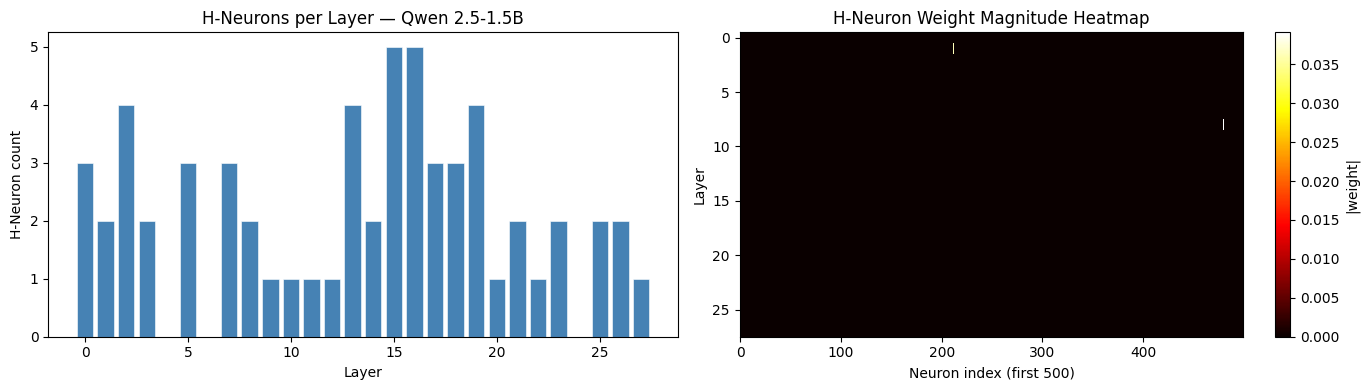

Figure saved.


In [16]:
import matplotlib.pyplot as plt

h_per_layer = h_neuron_mask.sum(axis=1)
fig, axes   = plt.subplots(1, 2, figsize=(14, 4))

axes[0].bar(range(NUM_LAYERS), h_per_layer, color="steelblue", edgecolor="white", linewidth=0.4)
axes[0].set_xlabel("Layer")
axes[0].set_ylabel("H-Neuron count")
axes[0].set_title("H-Neurons per Layer — Qwen 2.5-1.5B")

sample_cols = min(500, INTERMEDIATE_SIZE)
im = axes[1].imshow(np.abs(coef_answer_2d[:, :sample_cols]),
                    aspect="auto", cmap="hot", interpolation="nearest")
plt.colorbar(im, ax=axes[1], label="|weight|")
axes[1].set_xlabel(f"Neuron index (first {sample_cols})")
axes[1].set_ylabel("Layer")
axes[1].set_title("H-Neuron Weight Magnitude Heatmap")

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/h_neuron_distribution.png", dpi=150)
plt.show()
print("Figure saved.")

In [17]:
# ── Remove ALL stale hooks from every MLP layer ──────────────────────────────
for layer in model.model.layers:
    layer.mlp.act_fn._forward_hooks.clear()
    layer.mlp.act_fn._forward_pre_hooks.clear()

print("All stale hooks cleared.")

All stale hooks cleared.


In [18]:
import torch
import pandas as pd
from tqdm import tqdm

CLIP_MODE = "zero"  # "mean" | "second" | "zero"

clip_thresh = (
    second_thresh
    if CLIP_MODE == "second"
    else (mean_thresh if CLIP_MODE == "mean" else None)
)

print(f"Using clipping mode: {CLIP_MODE}")


def get_mlp_hook_target(layer):
    # ✅ FIX: hook BEFORE down_proj (intermediate size ~8960)
    return layer.mlp.up_proj


class ClipAndCollect:
    def __init__(self, is_hallucination):
        self.is_hallucination = is_hallucination

    def make_mlp_hook(self, layer_idx):
        mask_cpu = torch.from_numpy(h_neuron_mask[layer_idx]).bool()

        thresh_cpu = None
        if CLIP_MODE != "zero":
            thresh_np = clip_thresh[layer_idx][h_neuron_mask[layer_idx]].copy()
            thresh_cpu = torch.from_numpy(thresh_np)

        def _h(module, inp, out):
            if not self.is_hallucination:
                return None  # no modification

            dev, dtype = out.device, out.dtype

            mask = mask_cpu.to(device=dev)

            # Ensure mask shape matches last dim
            # mask: [d_ff] → broadcast to [1, 1, d_ff]
            mask_exp = mask.view(1, 1, -1)

            clipped = out.clone()

            if CLIP_MODE == "zero":
                clipped = clipped.masked_fill(mask_exp, 0.0)
            else:
                thresh = thresh_cpu.to(device=dev, dtype=dtype)
                thresh_exp = torch.zeros_like(out)
                thresh_exp[..., mask] = thresh

                clipped[..., mask] = out[..., mask].clamp(max=thresh)

            return clipped

        return _h


def run_clipped_forward(example):
    full_text = example["prompt"] + example.get("response_clean", example["response"])
    inputs = tokenizer(full_text, return_tensors="pt").to(DEVICE)

    controller = ClipAndCollect(example["label"] == 1)

    hooks = [
        get_mlp_hook_target(layer).register_forward_hook(controller.make_mlp_hook(li))
        for li, layer in enumerate(model.model.layers)
    ]

    try:
        with torch.no_grad():
            outputs = model(**inputs, output_hidden_states=True)
    finally:
        for h in hooks:
            h.remove()

    # Collect hidden states (residual stream, unchanged dimension 1536)
    return [
        outputs.hidden_states[li + 1].squeeze(0).mean(0).cpu().float().numpy()
        for li in range(NUM_LAYERS)
    ]


# ========================
# Run over dataset
# ========================

rows = []

for ex in tqdm(consistent_examples, desc=f"Forward pass [{CLIP_MODE}]"):
    hs = run_clipped_forward(ex)

    row = {"hallucination_label": ex["label"]}
    for li, h in enumerate(hs):
        row[f"state_{li}"] = h

    rows.append(row)

df_clipped = pd.DataFrame(rows)

print(f"Done — {df_clipped.shape}")
print(f"  Hallucinations: {(df_clipped.hallucination_label==1).sum()}")
print(f"  Faithful:       {(df_clipped.hallucination_label==0).sum()}")

Using clipping mode: zero


NameError: name 'consistent_examples' is not defined

Layers: 28
Saved: Qwen2.5-1.5B_zero_clipped_zero_layer_analysis.png


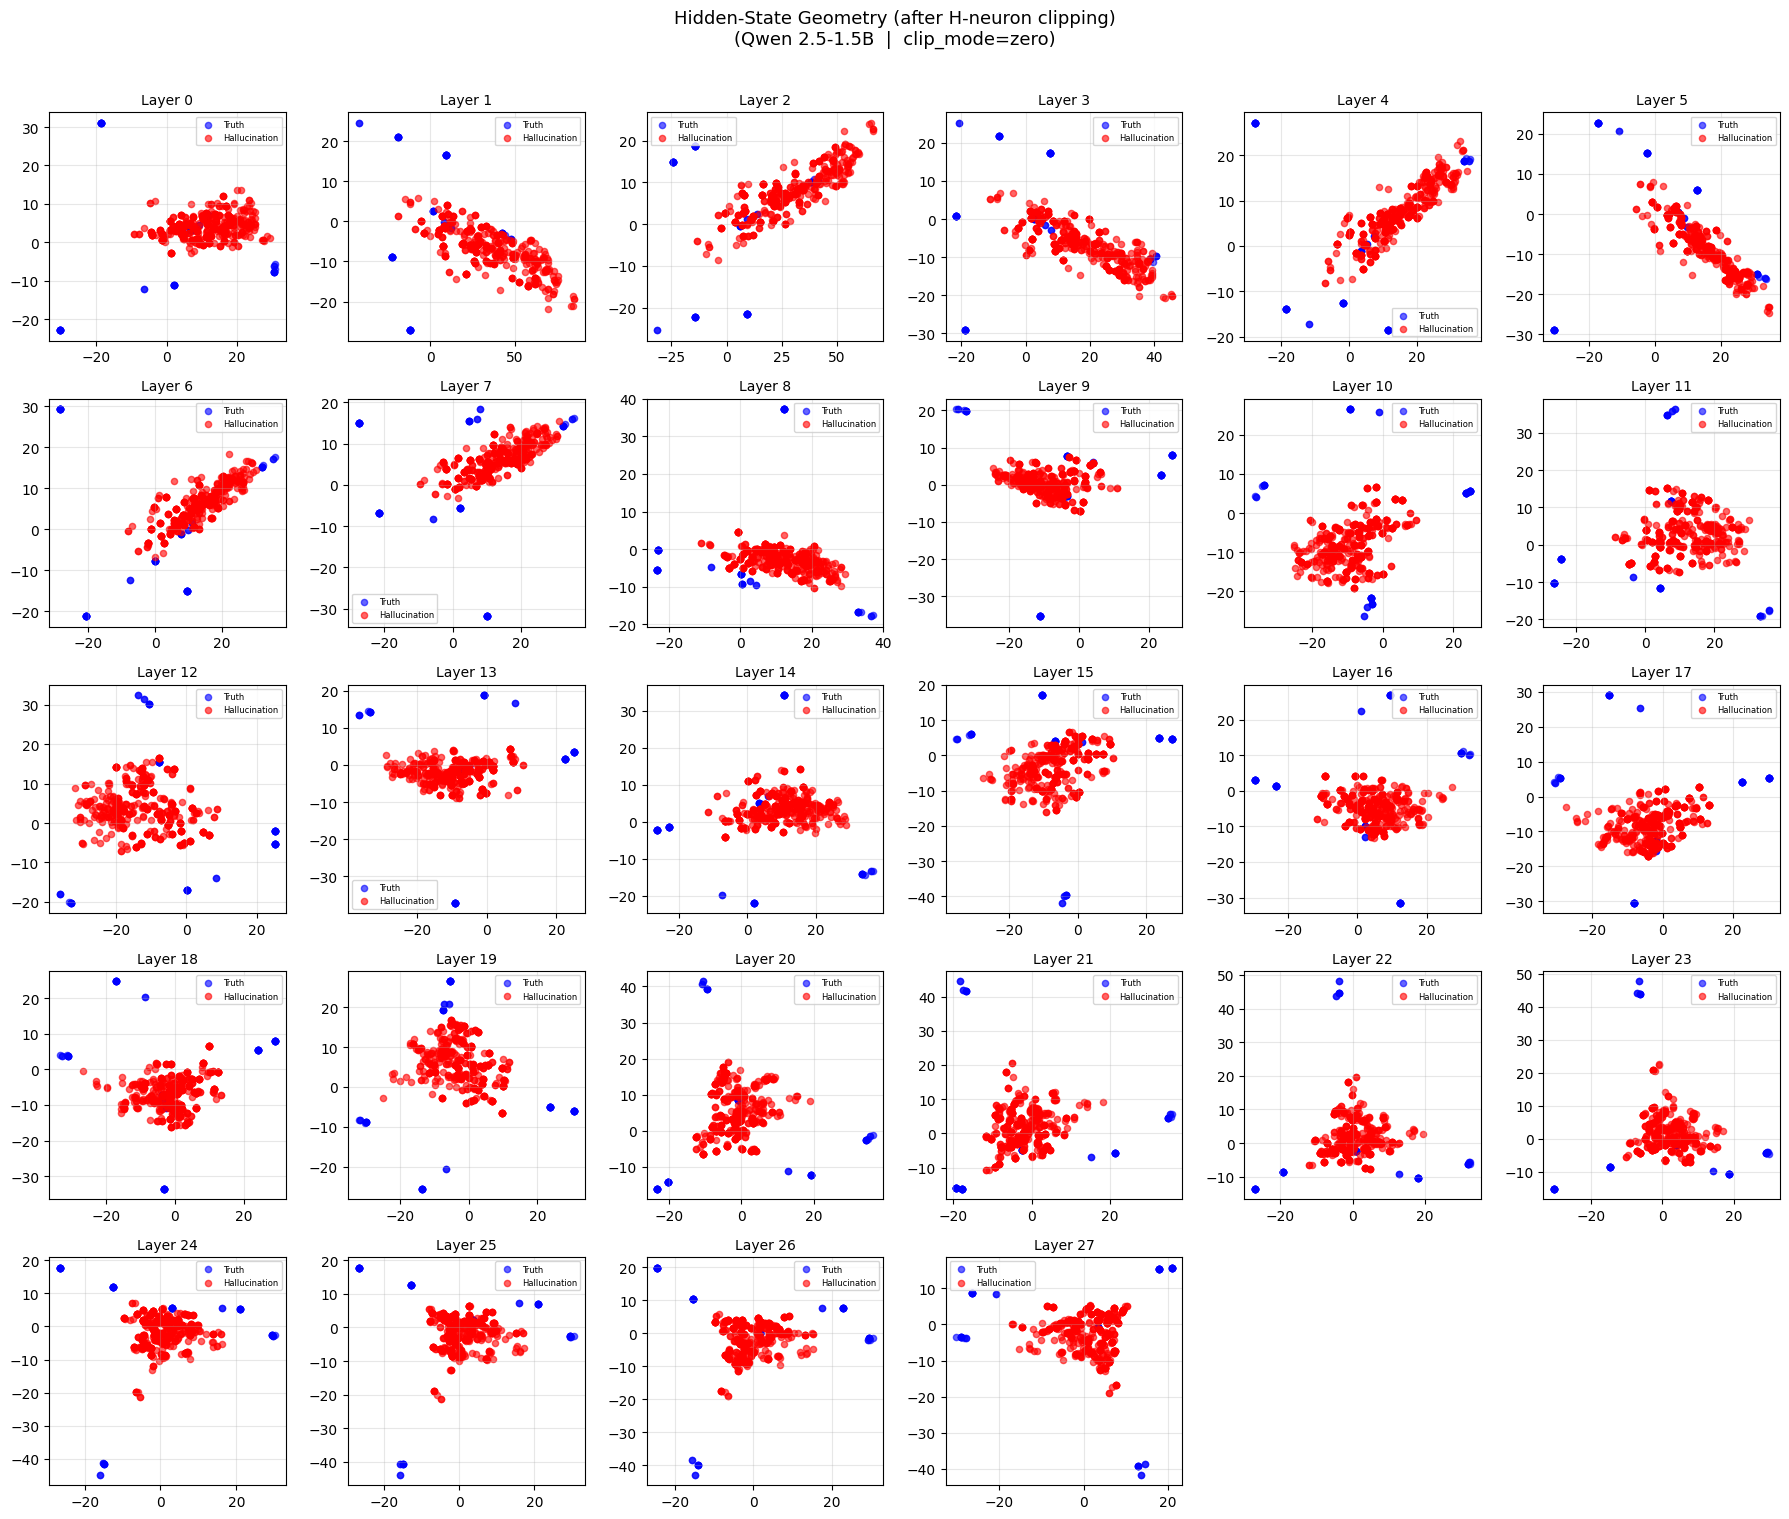

In [23]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import re


def analyzeLayers_clipped(df, title_suffix="(after H-neuron clipping)"):
    state_columns = [c for c in df.columns if c.startswith("state_")]
    n_layers = len(state_columns)

    truths        = []
    hallucinations = []
    for col in state_columns:
        truths.append(df[df["hallucination_label"] == 0][col].values)
        hallucinations.append(df[df["hallucination_label"] == 1][col].values)

    print(f"Layers: {n_layers}")

    n_cols = 6
    n_rows = (n_layers + n_cols - 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 3 * n_rows))
    axes = axes.flatten()

    for i in range(n_layers):
        try:
            # Stack arrays (each is already (hidden_size,) — no padding needed)
            tt = np.stack(truths[i])        # (n_truth, hidden)
            ff = np.stack(hallucinations[i]) # (n_hallu, hidden)

            scaler  = StandardScaler()
            tt_sc   = scaler.fit_transform(tt)
            ff_sc   = scaler.transform(ff)

            pca     = PCA(n_components=2)
            tt_2d   = pca.fit_transform(tt_sc)
            ff_2d   = pca.transform(ff_sc)

            axes[i].scatter(tt_2d[:,0], tt_2d[:,1],
                            color="blue",  label="Truth",        alpha=0.6, s=20)
            axes[i].scatter(ff_2d[:,0], ff_2d[:,1],
                            color="red",   label="Hallucination", alpha=0.6, s=20)
            axes[i].set_title(f"Layer {i}", fontsize=10)
            axes[i].legend(fontsize=6)
            axes[i].grid(True, alpha=0.3)

        except Exception as e:
            axes[i].text(0.5, 0.5, f"Layer {i}\nError: {e}",
                         ha="center", va="center", transform=axes[i].transAxes,
                         fontsize=7)
            axes[i].axis("off")

    for i in range(n_layers, len(axes)):
        axes[i].axis("off")

    fig.suptitle(
        f"Hidden-State Geometry {title_suffix}\n"
        f"(Qwen 2.5-1.5B  |  clip_mode={CLIP_MODE})",
        fontsize=13, y=1.01
    )
    plt.tight_layout()

    out_name = f"Qwen2.5-1.5B_zero_clipped_{CLIP_MODE}_layer_analysis.png"
    plt.savefig(out_name, dpi=150, bbox_inches="tight")
    print(f"Saved: {out_name}")
    plt.show()


analyzeLayers_clipped(df_clipped)

In [19]:
# ═══════════════════════════════════════════════════════════════
# STEP A — Clear any stale hooks
# ═══════════════════════════════════════════════════════════════
for layer in model.model.layers:
    layer.mlp.act_fn._forward_hooks.clear()
    layer.mlp.act_fn._forward_pre_hooks.clear()
print("Hooks cleared.")

Hooks cleared.


In [20]:
# ═══════════════════════════════════════════════════════════════
# STEP B — Re-generate with H-neurons zeroed during generation
# ═══════════════════════════════════════════════════════════════


class ZeroHNeurons:
    def make_hook(self, layer_idx):
        mask_cpu = torch.from_numpy(h_neuron_mask[layer_idx])

        def _h(module, inp, out):
            mask = mask_cpu.to(device=out.device)
            clipped = out.clone()  # ← was modifying out in-place
            clipped[..., mask] = 0.0
            return clipped

        return _h


def generate_zeroed(prompt: str) -> str:
    inputs = tokenizer(prompt, return_tensors="pt").to(DEVICE)
    controller = ZeroHNeurons()
    hooks = [
        get_mlp_hook_target(layer).register_forward_hook(controller.make_hook(li))
        for li, layer in enumerate(model.model.layers)
    ]
    try:
        with torch.no_grad():
            output = model.generate(
                **inputs,
                max_new_tokens=MAX_NEW_TOKENS,
                do_sample=False,
                pad_token_id=tokenizer.eos_token_id,
            )
    finally:
        for h in hooks:
            h.remove()
    gen_ids = output[0][inputs["input_ids"].shape[-1] :]
    raw = tokenizer.decode(gen_ids, skip_special_tokens=True).strip()
    return strip_thinking(raw) if NO_THINK else raw


print("Generating zeroed responses ...")
# Get one unique prompt per question
unique_questions = {}
for ex in consistent_examples:
    q = ex["question"]
    if q not in unique_questions:
        unique_questions[q] = ex   # store one example per question

unique_examples = list(unique_questions.values())
print(f"Unique questions: {len(unique_examples)}")  # should be ~100

# Generate one zeroed response per question
print("Generating zeroed responses ...")
zeroed_examples = []
for ex in tqdm(unique_examples, desc="Generating [H=0]"):
    new_response = generate_zeroed(ex["prompt"])
    zeroed_examples.append({
        "prompt":         ex["prompt"],
        "response":       new_response,
        "question":       ex["question"],
        "original_label": ex["label"],
    })

print(f"Generated {len(zeroed_examples)} responses.")
print(f"Generated {len(zeroed_examples)} responses.")
print("Sample (first example):")
print("  Original :", consistent_examples[0]["response"][:100])
print("  Zeroed   :", zeroed_examples[0]["response"][:100])

Generating zeroed responses ...


NameError: name 'consistent_examples' is not defined

In [26]:
import subprocess
import time
def run_ollama_serve():
    subprocess.Popen(["ollama", "serve"])

run_ollama_serve()
time.sleep(5) # Give the server a few seconds to start


In [27]:
!ollama signin

You are already signed in as user 'rachit'



In [28]:
# ═══════════════════════════════════════════════════════════════
# STEP C — Judge new responses with Ollama
# ═══════════════════════════════════════════════════════════════

def judge_response(question: str, response: str) -> int:
    """Returns 1 if hallucinated, 0 if correct."""
    prompt = (
        "<prompt>\n"
        "You are an expert evaluator tasked with determining whether a language model's "
        "output contains hallucinations.\n\n"
        "<input>\n"
        f"<question>{question}</question>\n"
        f"<model_output>{response}</model_output>\n"
        "</input>\n\n"
        "Does the model output correctly and factually answer the question?\n"
        "Respond with only:\n"
        "- 0 if there is NO hallucination\n"
        "- 1 if there IS a hallucination\n\n"
        "<hallucination>{0 or 1}</hallucination>\n"
        "</prompt>"
    )
    result  = client.chat(
        model=JUDGE_MODEL,
        messages=[{"role": "user", "content": prompt}]
    )
    content = result.message.content
    try:
        label = int(content.split("<hallucination>")[1].split("</hallucination>")[0].strip())
    except (IndexError, ValueError):
        label = 1 if "1" in content else 0
    return label


print("Judging zeroed responses ...")
for i, ex in enumerate(tqdm(zeroed_examples, desc="Judging [H=0]")):
    ex["hallucination_label"] = judge_response(ex["question"], ex["response"])
    if (i + 1) % 50 == 0:
        n_hall = sum(e["hallucination_label"] for e in zeroed_examples if "hallucination_label" in e)
        print(f"  [{i+1}/{len(zeroed_examples)}]  hallucinations so far: {n_hall}")

n_hall  = sum(e["hallucination_label"] == 1 for e in zeroed_examples)
n_faith = sum(e["hallucination_label"] == 0 for e in zeroed_examples)
print(f"\nOriginal  — hallucinatory: {sum(e['label']==1 for e in consistent_examples)}  faithful: {sum(e['label']==0 for e in consistent_examples)}")
print(f"Zeroed    — hallucinatory: {n_hall}  faithful: {n_faith}")

Judging zeroed responses ...


Judging [H=0]:  83%|████████▎ | 50/60 [03:15<00:30,  3.05s/it]

  [50/60]  hallucinations so far: 34


Judging [H=0]: 100%|██████████| 60/60 [03:49<00:00,  3.83s/it]


Original  — hallucinatory: 501  faithful: 59
Zeroed    — hallucinatory: 42  faithful: 18


In [29]:
# ═══════════════════════════════════════════════════════════════
# STEP D — Collect hidden states from new responses (clean forward pass)
# ═══════════════════════════════════════════════════════════════

def get_hidden_states(example: dict) -> list:
    """Clean forward pass — no hooks — on the zeroed response."""
    full_text = example["prompt"] + example["response"]
    inputs    = tokenizer(full_text, return_tensors="pt").to(DEVICE)
    with torch.no_grad():
        outputs = model(**inputs, output_hidden_states=True)
    return [
        outputs.hidden_states[li+1].squeeze(0).mean(0).cpu().float().numpy()
        for li in range(NUM_LAYERS)
    ]


print("Collecting hidden states ...")
rows = []
for ex in tqdm(zeroed_examples, desc="Hidden states [H=0]"):
    hs = get_hidden_states_fast(ex)
    row = {"hallucination_label": ex["hallucination_label"]}
    for li, h in enumerate(hs):
        row[f"state_{li}"] = h
    rows.append(row)

df_zeroed = pd.DataFrame(rows)
print(f"Done — {df_zeroed.shape}")
print(f"  Hallucinations: {(df_zeroed.hallucination_label==1).sum()}")
print(f"  Faithful:       {(df_zeroed.hallucination_label==0).sum()}")

Hidden states [H=0]: 100%|██████████| 60/60 [00:02<00:00, 21.54it/s]

Done — (60, 29)
  Hallucinations: 42
  Faithful:       18


Saved: Qwen2.5-1.5B_H_zeroed_layer_analysis.png


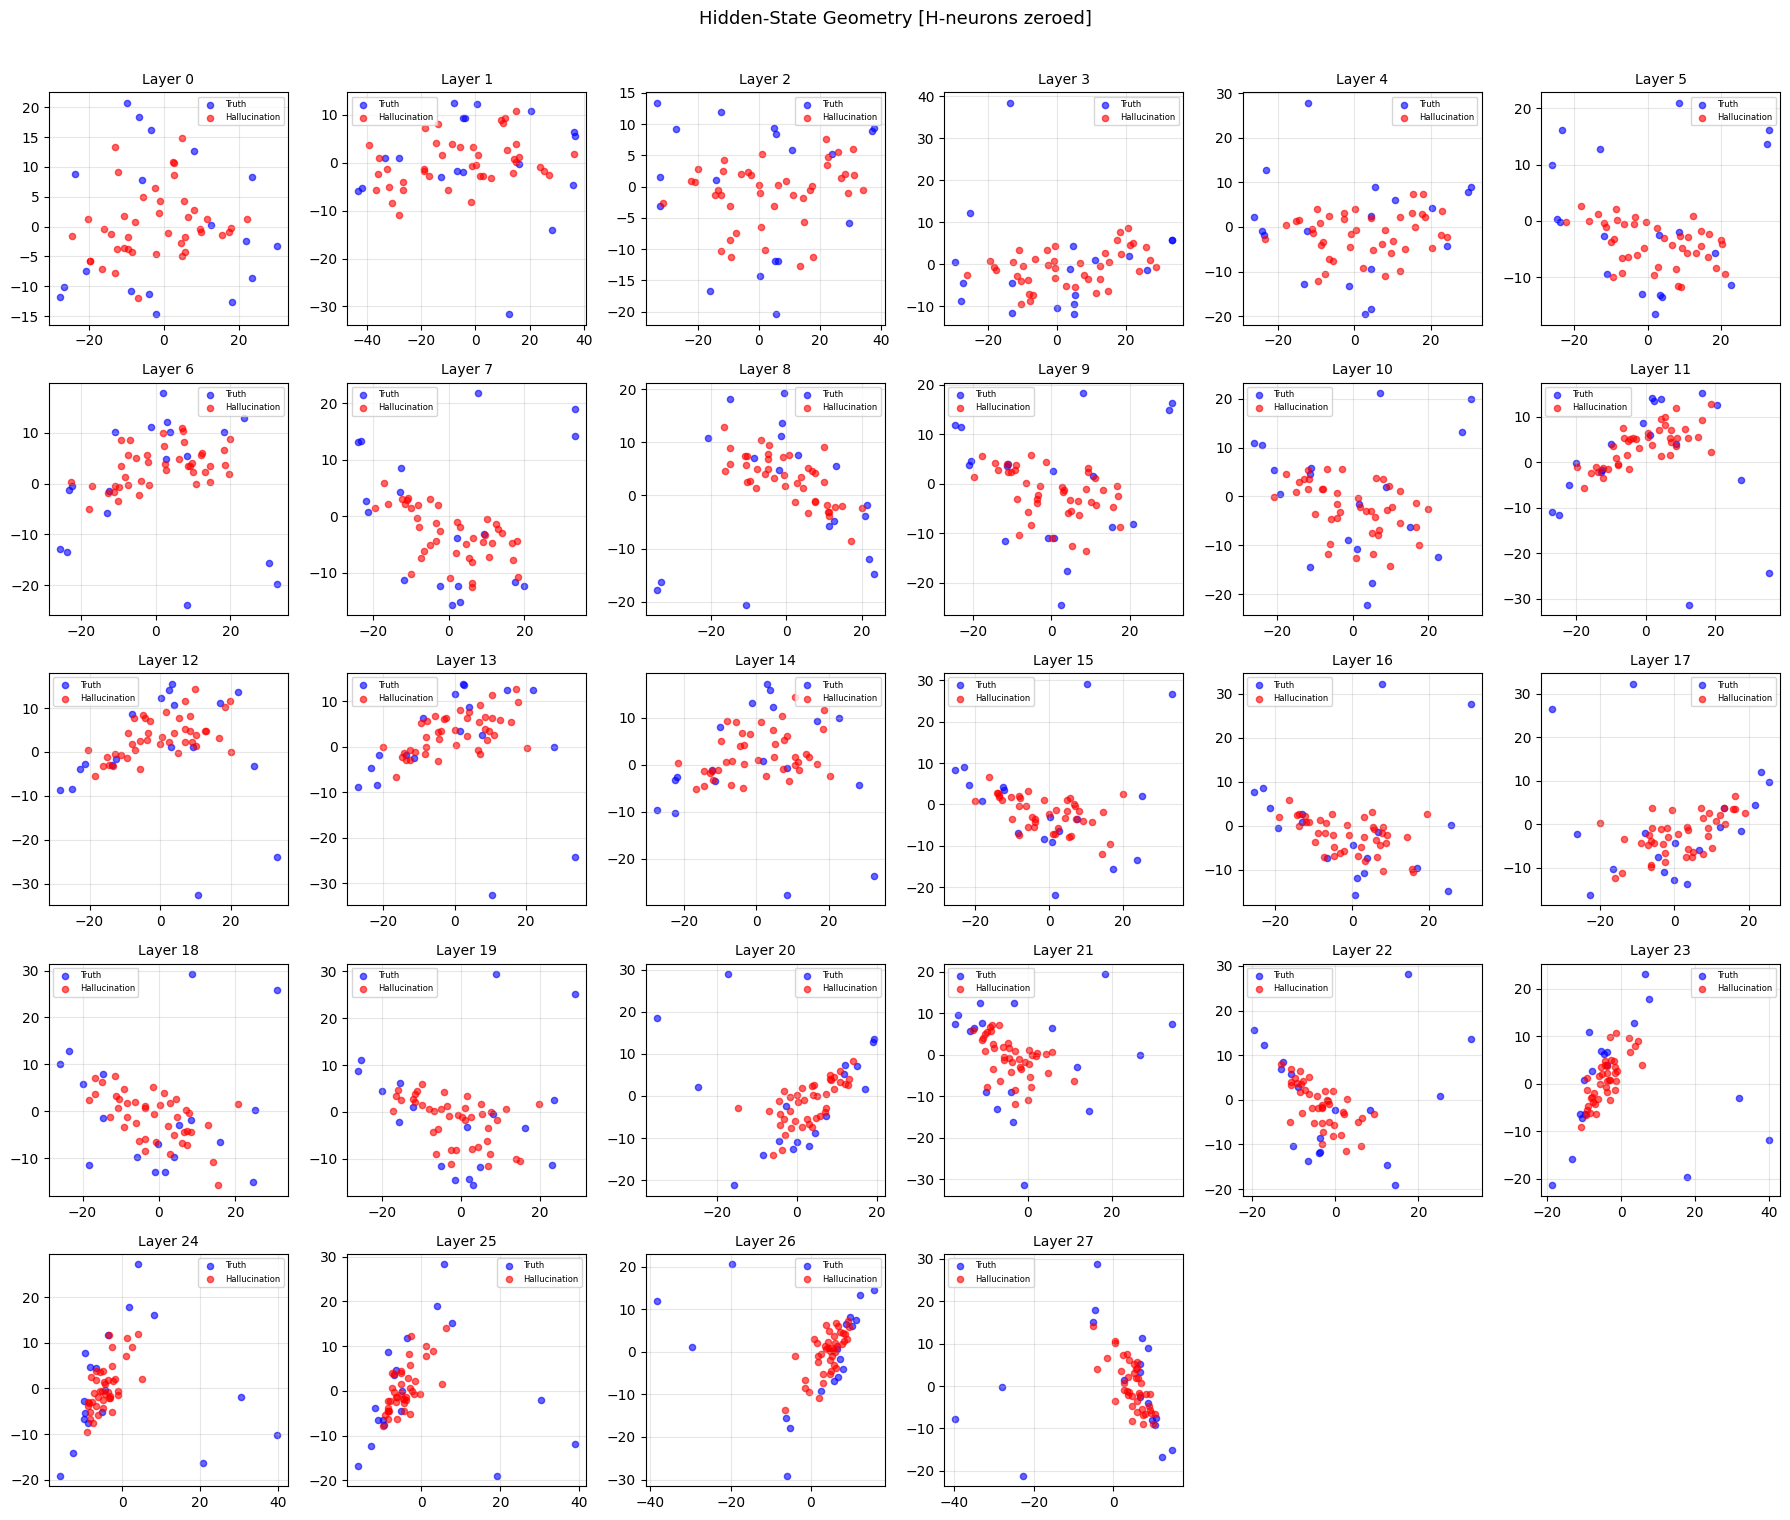

In [30]:
# ═══════════════════════════════════════════════════════════════
# STEP E — Plot (same analyzeLayers logic as original)
# ═══════════════════════════════════════════════════════════════
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

def analyzeLayers_zeroed(df, title="Hidden-State Geometry [H-neurons zeroed]"):
    state_cols = [c for c in df.columns if c.startswith("state_")]
    n_layers   = len(state_cols)
    n_cols     = 6
    n_rows     = (n_layers + n_cols - 1) // n_cols

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 3 * n_rows))
    axes = axes.flatten()

    for i, col in enumerate(state_cols):
        try:
            tt = np.stack(df[df["hallucination_label"]==0][col].values)
            ff = np.stack(df[df["hallucination_label"]==1][col].values)

            scaler = StandardScaler()
            tt_sc  = scaler.fit_transform(tt)
            ff_sc  = scaler.transform(ff)

            pca    = PCA(n_components=2)
            tt_2d  = pca.fit_transform(tt_sc)
            ff_2d  = pca.transform(ff_sc)

            axes[i].scatter(tt_2d[:,0], tt_2d[:,1], c="blue", label="Truth",
                            alpha=0.6, s=20)
            axes[i].scatter(ff_2d[:,0], ff_2d[:,1], c="red",  label="Hallucination",
                            alpha=0.6, s=20)
            axes[i].set_title(f"Layer {i}", fontsize=10)
            axes[i].legend(fontsize=6)
            axes[i].grid(True, alpha=0.3)
        except Exception as e:
            axes[i].text(0.5, 0.5, f"Layer {i}\n{e}", ha="center", va="center",
                         transform=axes[i].transAxes, fontsize=7)
            axes[i].axis("off")

    for i in range(n_layers, len(axes)):
        axes[i].axis("off")

    fig.suptitle(title, fontsize=13, y=1.01)
    plt.tight_layout()
    fname = "Qwen2.5-1.5B_H_zeroed_layer_analysis.png"
    plt.savefig(fname, dpi=150, bbox_inches="tight")
    print(f"Saved: {fname}")
    plt.show()

analyzeLayers_zeroed(df_zeroed)

In [31]:
def compute_cett_with_mask(example, previous_masks):
    full_text = example["prompt"] + example.get("response_clean", example["response"])
    inputs = tokenizer(full_text, return_tensors="pt").to(DEVICE)
    ans_mask = get_answer_token_mask(
        full_text, example["answer_span"], inputs["input_ids"]
    ).to(DEVICE)
    other_mask = ~ans_mask

    if ans_mask.sum() == 0:
        return None, None

    # Build cumulative zero mask from all previous iterations
    cumulative = None
    if previous_masks:
        cumulative = np.zeros_like(previous_masks[0], dtype=bool)
        for m in previous_masks:
            cumulative |= m

    hook_store = MlpNeuronHook()
    hooks = []

    for layer_idx, layer in enumerate(model.model.layers):
        target = get_mlp_hook_target(layer)

        if cumulative is not None:
            # Zero out previously found H-neurons during this forward pass
            layer_mask = torch.from_numpy(cumulative[layer_idx])

            def make_zero_hook(lmask, lidx):
                def _h(module, inp, out):
                    # Zero previous H-neurons from the output
                    m = lmask.to(device=out.device)
                    out = out.clone()
                    out[..., m] = 0.0
                    # Store the masked activation for CETT
                    hook_store.activations[lidx] = inp[0].detach().float().squeeze(0)
                    return out

                return _h

            hooks.append(
                target.register_forward_hook(make_zero_hook(layer_mask, layer_idx))
            )
        else:
            hooks.append(target.register_forward_hook(hook_store.hook_fn(layer_idx)))

    with torch.no_grad():
        outputs = model(**inputs, output_hidden_states=True)
    for h in hooks:
        h.remove()

    first_act = next(iter(hook_store.activations.values()))
    actual_intermediate = first_act.shape[-1]
    cett_answer = np.zeros((NUM_LAYERS, actual_intermediate), dtype=np.float32)
    cett_other = np.zeros((NUM_LAYERS, actual_intermediate), dtype=np.float32)

    for layer_idx in range(NUM_LAYERS):
        if layer_idx not in hook_store.activations:
            continue
        neuron_acts = hook_store.activations[layer_idx]
        h_total = outputs.hidden_states[layer_idx + 1].squeeze(0).float()
        h_norm = torch.norm(h_total, dim=-1, keepdim=True).clamp(min=1e-8)
        W_down = get_mlp_hook_target(model.model.layers[layer_idx]).weight.float()
        neuron_norms = torch.norm(W_down, dim=0)
        contribs = (neuron_acts.abs() * neuron_norms.unsqueeze(0)) / h_norm

        if ans_mask.sum() > 0:
            cett_answer[layer_idx] = contribs[ans_mask].mean(0).cpu().detach().numpy()
        if other_mask.sum() > 0:
            cett_other[layer_idx] = contribs[other_mask].mean(0).cpu().detach().numpy()

    return cett_answer, cett_other


def generate_zeroed_from_mask(prompt: str, mask: np.ndarray) -> str:
    inputs = tokenizer(prompt, return_tensors="pt").to(DEVICE)

    def make_hook(layer_mask):
        m_cpu = torch.from_numpy(layer_mask)

        def _h(module, inp, out):
            m = m_cpu.to(device=out.device)
            clipped = out.clone()
            clipped[..., m] = 0.0
            return clipped

        return _h

    hooks = [
        get_mlp_hook_target(layer).register_forward_hook(make_hook(mask[li]))
        for li, layer in enumerate(model.model.layers)
    ]
    try:
        with torch.no_grad():
            output = model.generate(
                **inputs,
                max_new_tokens=MAX_NEW_TOKENS,
                do_sample=False,
                pad_token_id=tokenizer.eos_token_id,
            )
    finally:
        for h in hooks:
            h.remove()

    gen_ids = output[0][inputs["input_ids"].shape[-1] :]
    raw = tokenizer.decode(gen_ids, skip_special_tokens=True).strip()
    return strip_thinking(raw) if NO_THINK else raw

In [1]:

import torch
import numpy as np
import pandas as pd
from tqdm import tqdm
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler


# =========================
# CONFIG
# =========================

N_ITERATIONS = 5
LASSO_C = 0.1
MAX_ITER = 1000
MAX_NEW_TOKENS = 128

DEVICE = next(model.parameters()).device
NUM_LAYERS = len(model.model.layers)
NUM_NEURONS = model.model.layers[0].mlp.up_proj.out_features  # ~8960

print("Using neuron dim:", NUM_NEURONS)


# =========================
# MLP ACTIVATION COLLECTOR
# =========================

class MLPCollector:
    def __init__(self, model, mask=None):
        self.model = model
        self.mask = mask
        self.handles = []
        self.activations = []

    def _make_hook(self, layer_idx):
        mask_cpu = None
        if self.mask is not None:
            mask_cpu = torch.from_numpy(self.mask[layer_idx]).bool()

        def hook(module, inp, out):
            # out: [batch, seq, 8960]

            if mask_cpu is not None:
                m = mask_cpu.to(out.device).view(1, 1, -1)
                out = out.masked_fill(m, 0.0)

            # store mean pooled activation
            self.activations.append(
                out.detach().mean(dim=1).squeeze(0).cpu().float().numpy()
            )

            return out

        return hook

    def __enter__(self):
        self.activations = []
        for li, layer in enumerate(self.model.model.layers):
            h = layer.mlp.up_proj.register_forward_hook(self._make_hook(li))
            self.handles.append(h)
        return self

    def __exit__(self, exc_type, exc_val, exc_tb):
        for h in self.handles:
            h.remove()
        self.handles = []


# =========================
# CETT IN MLP SPACE
# =========================

def compute_cett_with_mask(example, cumulative_mask=None):
    full_text = example["prompt"] + example.get("response_clean", example["response"])
    inputs = tokenizer(full_text, return_tensors="pt").to(DEVICE)

    with MLPCollector(model, cumulative_mask) as collector:
        with torch.no_grad():
            _ = model(**inputs)

    acts = np.stack(collector.activations)  # [layers, neurons]

    # simple placeholder split (you can refine later)
    return acts, acts.copy()


# =========================
# GENERATION WITH MASK
# =========================

def generate_zeroed_from_mask(prompt, cumulative_mask):

    inputs = tokenizer(prompt, return_tensors="pt").to(DEVICE)

    handles = []

    for li, layer in enumerate(model.model.layers):
        mask_cpu = torch.from_numpy(cumulative_mask[li]).bool()

        def make_hook(mask_cpu):
            def hook(module, inp, out):
                m = mask_cpu.to(out.device).view(1, 1, -1)
                return out.masked_fill(m, 0.0)
            return hook

        h = layer.mlp.up_proj.register_forward_hook(make_hook(mask_cpu))
        handles.append(h)

    try:
        with torch.no_grad():
            output = model.generate(
                **inputs,
                max_new_tokens=MAX_NEW_TOKENS,
                do_sample=False,
            )
    finally:
        for h in handles:
            h.remove()

    return tokenizer.decode(output[0], skip_special_tokens=True)


# =========================
# INITIAL DATA
# =========================

current_examples = consistent_examples.copy()

all_h_neuron_masks = []
iteration_stats = []
all_zeroed_by_iteration = []


# =========================
# MAIN LOOP
# =========================

for iteration in range(N_ITERATIONS):

    print("\n" + "="*50)
    print(f"ITERATION {iteration + 1}")
    print("="*50)

    print("Examples:", len(current_examples))
    print("Hallucinated:", sum(e["label"] == 1 for e in current_examples))
    print("Faithful:", sum(e["label"] == 0 for e in current_examples))


    # -------------------------
    # 1. CETT extraction
    # -------------------------

    skipped = 0

    for ex in tqdm(current_examples, desc=f"CETT iter {iteration+1}"):

        ca, co = compute_cett_with_mask(ex, cumulative_mask=None)

        ex[f"cett_answer_{iteration}"] = ca
        ex[f"cett_other_{iteration}"] = co


    # filter valid
    current_examples = [
        e for e in current_examples
        if f"cett_answer_{iteration}" in e
    ]


    # -------------------------
    # 2. Build probe dataset
    # -------------------------

    X_rows = []
    y = []

    for ex in current_examples:

        ca = ex[f"cett_answer_{iteration}"].flatten()
        co = ex[f"cett_other_{iteration}"].flatten()

        feat = np.concatenate([ca, co])

        if ex["label"] == 1:
            X_rows.append(feat)
            y.append(1)

            # negative synthetic example
            X_rows.append(np.concatenate([np.zeros_like(ca), co]))
            y.append(0)
        else:
            X_rows.append(feat)
            y.append(0)


    X = np.stack(X_rows).astype(np.float32)
    y = np.array(y, dtype=np.int32)

    if y.sum() == 0 or (y == 0).sum() == 0:
        print("No class balance — stopping")
        break


    scaler = StandardScaler()
    X = scaler.fit_transform(X)

    clf = LogisticRegression(
        penalty="l1",
        C=LASSO_C,
        solver="liblinear",
        max_iter=MAX_ITER,
        class_weight="balanced",
        random_state=42,
    )

    clf.fit(X, y)


    # -------------------------
    # 3. Extract MLP neuron mask
    # -------------------------

    n_half = NUM_LAYERS * NUM_NEURONS

    coef = clf.coef_[0][:n_half].reshape(NUM_LAYERS, NUM_NEURONS)

    # top-k selection (stable + prevents explosion)
    k = 40
    new_mask = np.zeros_like(coef, dtype=bool)

    for li in range(NUM_LAYERS):
        topk = np.argsort(coef[li])[-k:]
        new_mask[li, topk] = True

    print("New neurons:", int(new_mask.sum()))

    if new_mask.sum() == 0:
        print("Converged")
        break

    all_h_neuron_masks.append(new_mask)


    # -------------------------
    # 4. cumulative mask
    # -------------------------

    cumulative_mask = np.zeros_like(all_h_neuron_masks[0], dtype=bool)

    for m in all_h_neuron_masks:
        cumulative_mask |= m

    print("Cumulative neurons:", int(cumulative_mask.sum()))


    # -------------------------
    # 5. regenerate
    # -------------------------

    print("Generating with mask...")

    unique_questions = {
        e["question"]: e for e in current_examples
    }

    next_examples = []

    for ex in tqdm(unique_questions.values(), desc="Generate"):

        new_response = generate_zeroed_from_mask(
            ex["prompt"],
            cumulative_mask
        )

        next_examples.append({
            "prompt": ex["prompt"],
            "response": new_response,
            "response_clean": new_response,
            "question": ex["question"],
            "label": ex["label"],
        })


    # -------------------------
    # 6. judge
    # -------------------------

    print("Judging...")

    for ex in tqdm(next_examples):

        ex["label"] = judge_response(
            ex["question"],
            ex["response_clean"]
        )


    n_hall = sum(e["label"] == 1 for e in next_examples)
    n_faith = sum(e["label"] == 0 for e in next_examples)

    print(f"Hallucinated: {n_hall} Faithful: {n_faith}")


    # -------------------------
    # 7. update spans
    # -------------------------

    for ex in tqdm(next_examples):
        ex["answer_span"] = extract_answer_span_batch(
            ex["question"],
            ex["response_clean"]
        )


    iteration_stats.append({
        "iteration": iteration + 1,
        "new_neurons": int(new_mask.sum()),
        "cumulative_neurons": int(cumulative_mask.sum()),
        "hallucinated": n_hall,
        "faithful": n_faith,
    })


    if n_hall == 0:
        print("All hallucinations eliminated")
        break

    all_zeroed_by_iteration.append(next_examples)
    current_examples = next_examples


# =========================
# SUMMARY
# =========================

print("\nDONE\n")

for s in iteration_stats:
    print(
        f"Iter {s['iteration']}: "
        f"new={s['new_neurons']} "
        f"cum={s['cumulative_neurons']} "
        f"hall={s['hallucinated']}"
    )

NameError: name 'model' is not defined

In [ ]:
import json

viz_data = []

for iter_idx, stat in enumerate(iteration_stats):
    # Get the examples at this iteration
    # iteration 0 = original, iteration N = after N rounds of zeroing
    if iter_idx == 0:
        examples_at_iter = consistent_examples
    else:
        examples_at_iter = all_zeroed_by_iteration[
            iter_idx - 1
        ]  # store these during the loop

    # PCA per layer
    state_cols = [f"state_{li}" for li in range(NUM_LAYERS)]
    df_iter = pd.DataFrame(
        [
            {
                "label": ex["label"],
                **{
                    f"state_{li}": hs
                    for li, hs in enumerate(get_hidden_states_fast(ex))
                },
            }
            for ex in examples_at_iter
        ]
    )

    layer_pcas = []
    for li in range(NUM_LAYERS):
        col = f"state_{li}"
        tt = np.stack(df_iter[df_iter["label"] == 0][col].values)
        ff = np.stack(df_iter[df_iter["label"] == 1][col].values)
        if len(tt) < 2 or len(ff) < 2:
            layer_pcas.append(None)
            continue
        scaler = StandardScaler()
        combined = scaler.fit_transform(np.vstack([tt, ff]))
        pca = PCA(n_components=2)
        combined_2d = pca.fit_transform(combined)
        tt_2d = combined_2d[: len(tt)]
        ff_2d = combined_2d[len(tt) :]
        layer_pcas.append(
            {
                "truth": tt_2d.tolist(),
                "hallucination": ff_2d.tolist(),
                "variance_explained": pca.explained_variance_ratio_.tolist(),
            }
        )

    # Pick one true and one false example
    true_ex = next((e for e in examples_at_iter if e["label"] == 0), None)
    false_ex = next((e for e in examples_at_iter if e["label"] == 1), None)

    viz_data.append(
        {
            "iteration": iter_idx,
            "n_hallucinated": stat["hallucinated"],
            "n_faithful": stat["faithful"],
            "new_h_neurons": stat["new_h_neurons"],
            "cumulative_h_neurons": stat["cumulative_h_neurons"],
            "layer_pcas": layer_pcas,
            "true_example": {
                "question": true_ex["question"] if true_ex else "",
                "response": (
                    true_ex.get("response_clean", true_ex["response"])
                    if true_ex
                    else ""
                ),
            },
            "false_example": {
                "question": false_ex["question"] if false_ex else "",
                "response": (
                    false_ex.get("response_clean", false_ex["response"])
                    if false_ex
                    else ""
                ),
            },
        }
    )

with open(f"{OUTPUT_DIR}/viz_data.json", "w") as f:
    json.dump(viz_data, f)
print(f"Saved viz_data.json — {len(viz_data)} iterations")